# **Practice Lab Assignment 1** - Neural Network Implementation from Scratch



#**Submitted By:**

**Name:** Sakshi Walunj  
**PRN No:** 202502110007  
**Batch:** A3   
**Course:** Generative AI Lab  
**Department:** CSE (AI & ML)  
**Submission Date:** 15-Aug-2026
## **Objective**

Implement a simple feedforward neural network from scratch in Python without using any in-built deep learning libraries. This implementation focuses on the basic steps of a neural network such as forward pass, backward propagation (backpropagation), loss calculation, and training using gradient descent.


## Detailed Explanation

### MNIST Dataset:

The MNIST dataset contains handwritten digit images from 0 to 9. Each image has a size of 28 × 28 pixels, which gives 784 input values after flattening the image. The pixel values are normalized between 0 and 1 before giving them to the neural network.

### ReLU and Derivative:

`relu(x)` is used as the activation function in the hidden layer. It keeps positive values and changes negative values to 0. `relu_derivative(x)` gives the derivative of ReLU, which is needed during backpropagation to calculate how the error should be passed to the previous layer.

### Softmax:

`softmax(x)` is used in the output layer because this is a 10-class classification problem. It converts the output scores into probabilities for digits 0 to 9. The probabilities add up to 1, and the digit with the highest probability is taken as the prediction.

### Cross-Entropy Loss:

Cross-entropy loss is used to measure the difference between the actual digit and the predicted probabilities. A lower loss means that the network is making predictions closer to the correct labels.

### Neural Network Class:

The `NeuralNetwork` class contains the methods used to initialize the weights and biases, perform the forward pass, perform backpropagation, and update the parameters using gradient descent.

### Forward Pass:

The forward pass takes the input image and passes it through the network. First, the input values are multiplied with the weights and added to the bias. ReLU is then applied to the hidden layer. The output layer uses Softmax to produce the probability of each digit.

### Backward Pass (Backpropagation):

During the backward pass, the difference between the predicted output and the actual output is calculated. This error is passed backwards through the output and hidden layers to calculate the gradients of the weights and biases. These gradients are then used to update the parameters.

### Training Method:

The network is trained using mini-batch gradient descent. The training data is divided into small batches. For every batch, the network performs a forward pass, calculates the error, performs backpropagation, and updates the weights and biases. This process is repeated for several epochs so that the network gradually improves its predictions.

A separate validation set is used only to check the model during training. The final test set is kept aside and is used only after training is completed.

### Evaluation:

After training, the network is evaluated on the test images. Accuracy, precision, recall, F1-score, and a confusion matrix are used to understand the performance of the model. A Logistic Regression model is also used as a simple baseline for comparison.

## 1. Importing Required Libraries

NumPy is used for the neural network calculations and matrix operations. Matplotlib is used for displaying the MNIST images and training graphs. Scikit-learn is used only for loading the dataset, splitting the data, and calculating evaluation metrics.

In [9]:
# Import NumPy for array operations and calculations
import numpy as np

# Import Matplotlib for displaying images and graphs
import matplotlib.pyplot as plt

# Import functions needed to load and split the dataset
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Import evaluation metrics used later
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Keep the random results consistent each time
np.random.seed(42)

In [10]:
# Load the MNIST handwritten digit dataset
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

# Convert the pixel values to float and normalize them from 0-255 to 0-1
X = mnist.data.astype(np.float32) / 255.0
y = mnist.target.astype(np.int64)

print("Full dataset:", X.shape)
print("Labels:", y.shape)

# Select 12,000 images while keeping the digit classes balanced
X_small, _, y_small, _ = train_test_split(
    X, y, train_size=12000, stratify=y, random_state=42
)

# Keep 2,000 images aside for the final test
# These images will not be used during training
X_temp, X_test, y_temp, y_test = train_test_split(
    X_small, y_small, test_size=2000, stratify=y_small, random_state=42
)

# Split the remaining 10,000 images into training and validation data
# Validation data is only used to check the model during training
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=2000, stratify=y_temp, random_state=42
)

print("Training samples  :", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Testing samples   :", X_test.shape[0])
print("Features per image:", X_train.shape[1])

Full dataset: (70000, 784)
Labels: (70000,)
Training samples  : 8000
Validation samples: 2000
Testing samples   : 2000
Features per image: 784


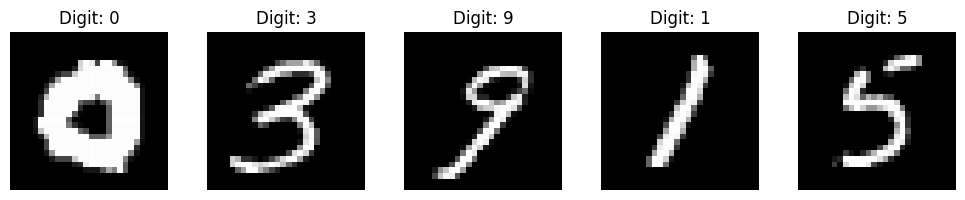

In [11]:
# Display a few MNIST images to see what the input data looks like
fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for i, ax in enumerate(axes):
    ax.imshow(X_train[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Digit: {y_train[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 2. Loading and Preparing the MNIST Dataset

The MNIST dataset is loaded and the pixel values are divided by 255 so that they fall between 0 and 1. A smaller stratified subset of 12,000 images is used so that the from-scratch training can run in a reasonable amount of time.

The data is divided into training, validation, and test sets. The validation set is used during training only for checking the model, while the test set is kept untouched until the final evaluation.

## 3. Neural Network Architecture

The network used in this practical has the architecture **784 → 64 → 10**.

The 784 input neurons represent the pixels of a 28 × 28 image. The hidden layer contains 64 neurons and uses ReLU activation. The output layer contains 10 neurons, one for each digit from 0 to 9, and uses Softmax to produce the final probabilities.

## 4. Mathematical Method Used

### Forward Pass

The input is passed through the network using the following equations:

Z₁ = XW₁ + b₁  
A₁ = ReLU(Z₁)  
Z₂ = A₁W₂ + b₂  
Ŷ = Softmax(Z₂)

### Backpropagation

For Softmax with cross-entropy loss, the output error can be written as:

dZ₂ = Ŷ − Y

The remaining gradients are calculated by moving the error backwards through the network.

### Gradient Descent

After calculating the gradients, the weights and biases are updated using:

W = W − learning rate × dW

This allows the network to reduce its loss and improve its predictions over the training epochs.

In [12]:
# ReLU Activation Function
def relu(z):
    # Keep positive values and change negative values to 0
    return np.maximum(0, z)


# Derivative of ReLU Activation Function
def relu_derivative(z):
    # The derivative is 1 for positive values and 0 for negative values
    return (z > 0).astype(np.float32)


# Softmax Activation Function
def softmax(z):
    # Subtract the largest value first to make the calculation stable
    z = z - np.max(z, axis=1, keepdims=True)

    # Calculate the exponent of each output value
    exp_z = np.exp(z)

    # Convert the values into probabilities
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


# Cross-Entropy Loss Function
def cross_entropy(y_true, y_prob):
    # Get the probability assigned to the correct class
    correct_prob = np.clip(
        y_prob[np.arange(len(y_true)), y_true], 1e-12, 1.0
    )

    # Calculate the average loss for the batch
    return -np.mean(np.log(correct_prob))


# Convert digit labels into one-hot form
def one_hot(y, classes=10):
    result = np.zeros((len(y), classes), dtype=np.float32)

    # Put 1 at the position of the correct digit
    result[np.arange(len(y)), y] = 1.0

    return result

## 5. Activation Functions and Loss Function

The hidden layer uses ReLU because it is simple and works well for this type of neural network. The output layer uses Softmax because the model has ten possible classes.

Cross-entropy is used as the loss function. It gives a higher loss when the model gives a low probability to the correct digit and a lower loss when the correct digit gets a high probability.

In [13]:
# Neural Network Class Definition
class NeuralNetwork:
    def __init__(
        self,
        input_size=784,
        hidden_size=64,
        output_size=10,
        learning_rate=0.1
    ):
        # Start the weights with small random values
        # He initialization is suitable for the ReLU hidden layer
        self.W1 = (
            np.random.randn(input_size, hidden_size)
            * np.sqrt(2 / input_size)
        ).astype(np.float32)

        # Start the first layer biases at 0
        self.b1 = np.zeros((1, hidden_size), dtype=np.float32)

        # Initialize the weights connecting the hidden layer to the output layer
        self.W2 = (
            np.random.randn(hidden_size, output_size)
            * np.sqrt(2 / hidden_size)
        ).astype(np.float32)

        # Start the output layer biases at 0
        self.b2 = np.zeros((1, output_size), dtype=np.float32)

        # Store the learning rate used during gradient descent
        self.learning_rate = learning_rate

    def forward(self, X):
        # Calculate the input received by each hidden neuron
        self.Z1 = X @ self.W1 + self.b1

        # Apply ReLU to the hidden layer
        self.A1 = relu(self.Z1)

        # Calculate the values going into the output layer
        self.Z2 = self.A1 @ self.W2 + self.b2

        # Convert the output values into probabilities for 10 digits
        self.A2 = softmax(self.Z2)

        return self.A2

    def backward(self, X, y):
        # Number of samples in the current batch
        m = len(X)

        # Convert the actual digit labels into one-hot form
        Y = one_hot(y)

        # Calculate the error at the output layer
        dZ2 = (self.A2 - Y) / m

        # Calculate gradients for the second layer weights and bias
        dW2 = self.A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        # Pass the error back from the output layer to the hidden layer
        dA1 = dZ2 @ self.W2.T

        # Apply the derivative of ReLU
        dZ1 = dA1 * relu_derivative(self.Z1)

        # Calculate gradients for the first layer weights and bias
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Update weights and biases using gradient descent
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2

    def predict_proba(self, X):
        # Return the probability of each digit
        return self.forward(X)

    def predict(self, X):
        # Select the digit with the highest probability
        return np.argmax(self.predict_proba(X), axis=1)

## 6. Neural Network Class Definition

The `NeuralNetwork` class contains the main working of the model. The constructor creates the weights and biases, the `forward()` method calculates the output, and the `backward()` method calculates the gradients and updates the parameters.

He initialization is used for the weights because the hidden layer uses ReLU activation. It starts the weights with suitable small random values instead of starting all weights at zero.

In [14]:
# Training Method
def train(model, X_train, y_train, X_val, y_val, epochs=15, batch_size=64):
    history = {
        "loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    for epoch in range(epochs):
        # Shuffle the training samples before starting the epoch
        indices = np.random.permutation(len(X_train))
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]

        # Train the model batch by batch
        for start in range(0, len(X_train), batch_size):
            end = start + batch_size

            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            # Forward pass: calculate predictions for this batch
            model.forward(X_batch)

            # Backward pass: calculate gradients and update the weights
            model.backward(X_batch, y_batch)

        # Check the training loss after all batches are completed
        train_prob = model.predict_proba(X_train)
        train_loss = cross_entropy(y_train, train_prob)

        # Calculate training accuracy
        train_acc = np.mean(
            np.argmax(train_prob, axis=1) == y_train
        )

        # Check validation accuracy without changing the weights
        val_prob = model.predict_proba(X_val)
        val_acc = np.mean(
            np.argmax(val_prob, axis=1) == y_val
        )

        # Save the results so they can be plotted later
        history["loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)

        # Display the progress after each epoch
        print(
            f"Epoch {epoch + 1:2d}/{epochs} | "
            f"Loss: {train_loss:.4f} | "
            f"Train Accuracy: {train_acc:.4f} | "
            f"Validation Accuracy: {val_acc:.4f}"
        )

    return history


# Create the neural network
model = NeuralNetwork(learning_rate=0.1)

# Train the network using mini-batch gradient descent
history = train(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=15,
    batch_size=64
)

Epoch  1/15 | Loss: 0.4330 | Train Accuracy: 0.8786 | Validation Accuracy: 0.8705
Epoch  2/15 | Loss: 0.3434 | Train Accuracy: 0.8998 | Validation Accuracy: 0.8960
Epoch  3/15 | Loss: 0.2958 | Train Accuracy: 0.9173 | Validation Accuracy: 0.9070
Epoch  4/15 | Loss: 0.2754 | Train Accuracy: 0.9214 | Validation Accuracy: 0.9100
Epoch  5/15 | Loss: 0.2364 | Train Accuracy: 0.9343 | Validation Accuracy: 0.9175
Epoch  6/15 | Loss: 0.2188 | Train Accuracy: 0.9385 | Validation Accuracy: 0.9205
Epoch  7/15 | Loss: 0.2037 | Train Accuracy: 0.9423 | Validation Accuracy: 0.9220
Epoch  8/15 | Loss: 0.1860 | Train Accuracy: 0.9477 | Validation Accuracy: 0.9340
Epoch  9/15 | Loss: 0.1717 | Train Accuracy: 0.9554 | Validation Accuracy: 0.9295
Epoch 10/15 | Loss: 0.1623 | Train Accuracy: 0.9555 | Validation Accuracy: 0.9355
Epoch 11/15 | Loss: 0.1500 | Train Accuracy: 0.9585 | Validation Accuracy: 0.9330
Epoch 12/15 | Loss: 0.1472 | Train Accuracy: 0.9584 | Validation Accuracy: 0.9305
Epoch 13/15 | Lo

## 7. Training the Neural Network

The network is trained using mini-batch gradient descent. Instead of using all training images at once, the images are divided into batches of 64.

For every batch, the network first makes a prediction, calculates the error, sends the error backward to calculate the gradients, and then updates the weights and biases. After all batches are completed, the training and validation performance is checked for that epoch.

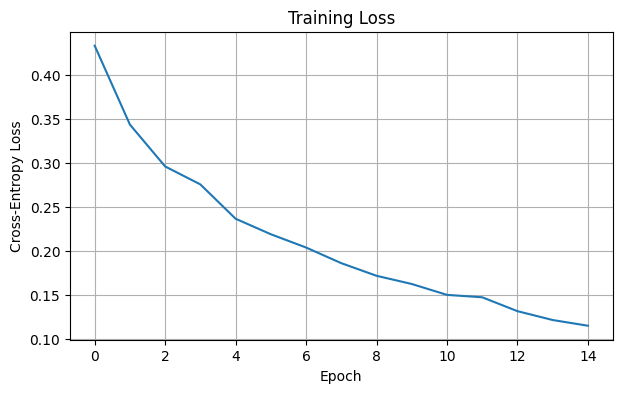

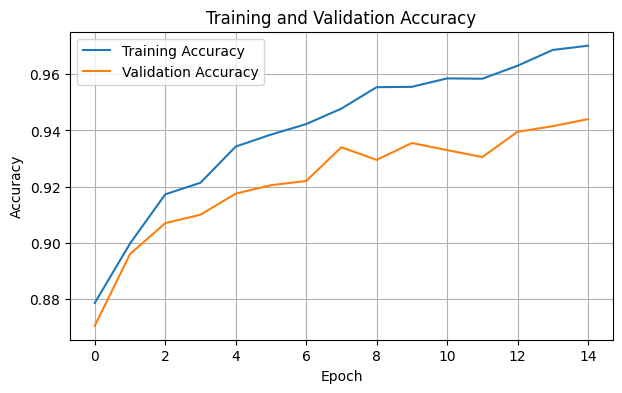

In [15]:
# Plot the loss after each training epoch
plt.figure(figsize=(7, 4))
plt.plot(history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

# Plot training and validation accuracy
plt.figure(figsize=(7, 4))
plt.plot(history["train_accuracy"], label="Training Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 8. Training Results

The training loss and accuracy graphs are used to see how the model changes during training. A decreasing loss generally means that the network is learning from the training data.

The validation accuracy is checked during training to see how the model performs on images that are not used for updating the weights.

Final Test Accuracy: 0.9450 (94.50%)

Classification Report:
              precision    recall  f1-score   support

           0     0.9548    0.9645    0.9596       197
           1     0.9489    0.9911    0.9696       225
           2     0.9598    0.9550    0.9574       200
           3     0.9275    0.9412    0.9343       204
           4     0.9378    0.9282    0.9330       195
           5     0.9543    0.9278    0.9408       180
           6     0.9500    0.9645    0.9572       197
           7     0.9567    0.9567    0.9567       208
           8     0.9184    0.9231    0.9207       195
           9     0.9415    0.8894    0.9147       199

    accuracy                         0.9450      2000
   macro avg     0.9450    0.9441    0.9444      2000
weighted avg     0.9450    0.9450    0.9448      2000



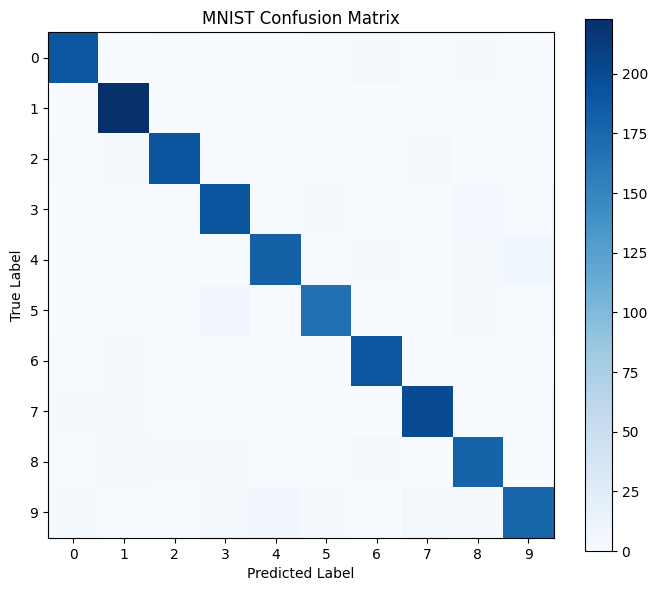

In [16]:
# Predict the digits in the untouched test set
y_pred = model.predict(X_test)

# Calculate the overall test accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Final Test Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")

# Print precision, recall and F1-score for each digit
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# Create a confusion matrix to see correct and incorrect predictions
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap="Blues")
plt.title("MNIST Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.xticks(range(10))
plt.yticks(range(10))
plt.tight_layout()
plt.show()

## 9. Final Evaluation

After all epochs are completed, the model is tested on the separate test set. This test set was not used for updating the weights or monitoring the model during training.

Accuracy gives the overall number of correct predictions, while precision, recall, and F1-score give more detail for each digit class. The confusion matrix shows which digits are classified correctly and which digits are confused with other digits.

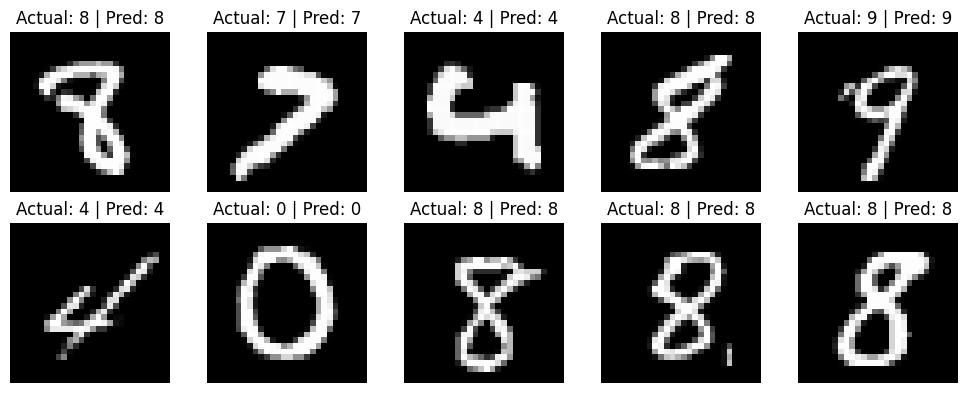

In [17]:
# Display a few test images with their actual and predicted digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_test[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Actual: {y_test[i]} | Pred: {y_pred[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 10. Sample Predictions

A few test images are displayed along with their actual and predicted labels. This makes it easier to see whether the network is correctly recognizing individual handwritten digits.

In [18]:
# Logistic Regression is used as a simple baseline model
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
baseline = LogisticRegression(
    max_iter=300,
    solver="lbfgs"
)

# Train the baseline using the same training data
baseline.fit(X_train, y_train)

# Predict the untouched test set
baseline_pred = baseline.predict(X_test)

# Calculate its test accuracy
baseline_accuracy = accuracy_score(y_test, baseline_pred)

print(f"Neural Network from Scratch: {accuracy:.4f}")
print(f"Logistic Regression        : {baseline_accuracy:.4f}")

Neural Network from Scratch: 0.9450
Logistic Regression        : 0.9015


## 11. Comparison with an Alternative Model

Logistic Regression is used as a simple model for comparison. It is a linear model, while the neural network has a hidden layer with ReLU activation.

Both models are trained using the same 8,000 training images and evaluated on the same 2,000 test images. The test images are kept separate from training, so the final accuracy gives a fair comparison between the two models.

## 12. Analysis of the Implemented Model

The training loss decreased from 0.4330 in the first epoch to 0.1149 in the last epoch. This shows that the network was learning and reducing its error during training. The training accuracy reached 97.01%, while the validation accuracy reached 94.40%.

The final test accuracy was 94.50%. From the confusion matrix, most of the predictions are on the diagonal, which means that most digits were classified correctly. Some mistakes occurred between digits with similar handwritten shapes. Digit 8 had a comparatively lower F1-score than some of the other classes.

Logistic Regression achieved 90.15% accuracy, while the neural network achieved 94.50%. The neural network performed better by 4.35 percentage points, showing that the hidden ReLU layer helped the model learn more complex patterns.

## 13. Conclusion

In this practical, a feedforward neural network was implemented from scratch using NumPy. The main steps, including forward propagation, activation functions, loss calculation, backpropagation, and gradient-descent updates, were implemented manually.

The model was trained and tested on the MNIST dataset. It achieved a final test accuracy of 94.50%. The model was also compared with Logistic Regression, which achieved 90.15% accuracy. The results show that the neural network was able to learn the handwritten digit patterns effectively.

## 14. Declaration

I, **Sakshi Walunj**, confirm that the work submitted in this assignment is my own and has been completed
following academic integrity guidelines. The code is uploaded on my GitHub repository account, and the
repository link is provided below:


**GitHub Repository Link:** https://github.com/Sakshiwalunj5/GenAI/tree/main/Assignment-1

**Signature:** Sakshi Uttam Walunj